In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 


In [7]:
import os

folder_path = r"C:\Users\pc\Desktop\foot_ball_data"

files = os.listdir(folder_path)

print(files)

['Football_Player_Market_Value_Trajectories']


In [9]:
import os

folder_path = r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Market_Value_Trajectories"

files = os.listdir(folder_path)

print(files)

['data_dictionary.csv', 'transfermarkt_player_values.csv', 'transfermarkt_player_values.parquet', 'transfermarkt_value_history.csv']


In [30]:
import pandas as pd

file_path = r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Market_Value_Trajectories\transfermarkt_player_values.csv"

df = pd.read_csv(file_path)

df.head()

,player_id,name,age,nationality,position,position_group,current_club,league_name,current_value_eur,current_value_tier,...,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,trajectory,is_at_peak,ever_100m,ever_50m,ever_10m,data_source,dataset_built_at
0,418560,Erling Haaland,25.0,Norway,€200.00m,Other,Norway,Premier League,200000000.0,World Class (100M+),...,1.6329,26,5,growing,0,1,1,1,Transfermarkt.com,2026-02-21
1,433177,Bukayo Saka,24.0,England,€130.00m,Other,England,Premier League,130000000.0,World Class (100M+),...,0.6972,22,1,growing,0,1,1,1,Transfermarkt.com,2026-02-21
2,357662,Declan Rice,27.0,England,€120.00m,Other,England,Premier League,120000000.0,World Class (100M+),...,1.6100,24,2,growing,0,1,1,1,Transfermarkt.com,2026-02-21
3,568177,Cole Palmer,23.0,England,€120.00m,Other,England,Premier League,120000000.0,World Class (100M+),...,2.0823,15,3,growing,0,1,1,1,Transfermarkt.com,2026-02-21
4,349066,Alexander Isak,26.0,Sweden,€120.00m,Other,Sweden,Premier League,120000000.0,World Class (100M+),...,1.5154,28,6,growing,0,1,1,1,Transfermarkt.com,2026-02-21


In [32]:
df2 = pd.read_csv(r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Market_Value_Trajectories\transfermarkt_value_history.csv")

df2.head()

,player_id,valuation_date,value_eur,value_display,club,age_at_date,year,month
0,108390,01/06/2016,35000000,€35.00m,Chelsea FC,24,2016,5
1,108390,01/07/2015,35000000,€35.00m,Chelsea FC,23,2015,6
2,108390,01/08/2012,15000000,€15.00m,Atlético de Madrid,20,2012,7
3,108390,01/08/2016,35000000,€35.00m,Chelsea FC,24,2016,7
4,108390,02/01/2018,50000000,€50.00m,Chelsea FC,25,2018,1


In [38]:
import pandas as pd

# Assuming df and df2 are already loaded
# df -> player summary
# df2 -> player valuation history

# Merge on player_id
merged_df = pd.merge(df, df2, on="player_id", how="left")  # 'left' keeps all players in summary

# Check the result
print(merged_df.head())
print("Merged dataset shape:", merged_df.shape)

   player_id            name   age nationality  position position_group  \
0     418560  Erling Haaland  25.0      Norway  €200.00m          Other   
1     418560  Erling Haaland  25.0      Norway  €200.00m          Other   
2     418560  Erling Haaland  25.0      Norway  €200.00m          Other   
3     418560  Erling Haaland  25.0      Norway  €200.00m          Other   
4     418560  Erling Haaland  25.0      Norway  €200.00m          Other   

  current_club     league_name  current_value_eur   current_value_tier  ...  \
0       Norway  Premier League        200000000.0  World Class (100M+)  ...   
1       Norway  Premier League        200000000.0  World Class (100M+)  ...   
2       Norway  Premier League        200000000.0  World Class (100M+)  ...   
3       Norway  Premier League        200000000.0  World Class (100M+)  ...   
4       Norway  Premier League        200000000.0  World Class (100M+)  ...   

   ever_10m        data_source dataset_built_at valuation_date  value_eur 

In [40]:
# Check total missing values per column
missing_values = merged_df.isna().sum()
print(missing_values[missing_values > 0])

age            101
nationality    101
dtype: int64


In [44]:
import pandas as pd

# Assuming merged_df is your merged dataset
df = merged_df.copy()

In [46]:
columns_to_keep = [
    'player_id', 'name', 'age', 'nationality', 'position', 'current_club', 
    'league_name', 'current_value_eur', 'valuation_date', 'value_eur', 
    'club', 'age_at_date', 'year', 'month'
]

df_clean = df[columns_to_keep]

In [58]:
import pandas as pd

# Copy relevant columns
columns_to_keep = [
    'player_id', 'name', 'age', 'nationality', 'position', 'current_club', 
    'league_name', 'current_value_eur', 'valuation_date', 'value_eur', 
    'club', 'age_at_date', 'year', 'month'
]

df_clean = merged_df[columns_to_keep].copy()  # copy to avoid SettingWithCopyWarning

# Convert types
df_clean['valuation_date'] = pd.to_datetime(df_clean['valuation_date'], dayfirst=True)
df_clean['value_eur'] = pd.to_numeric(df_clean['value_eur'], errors='coerce')
df_clean['current_value_eur'] = pd.to_numeric(df_clean['current_value_eur'], errors='coerce')
df_clean['age'] = pd.to_numeric(df_clean['age'], errors='coerce')
df_clean['age_at_date'] = pd.to_numeric(df_clean['age_at_date'], errors='coerce')

# Fill missing age and nationality
df_clean['age'] = df_clean['age'].fillna(df_clean['age_at_date'])
df_clean['nationality'] = df_clean.groupby('player_id')['nationality'].transform(lambda x: x.ffill().bfill())

# Remove duplicates and invalid rows
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean['value_eur'] > 0]

# Sort
df_clean = df_clean.sort_values(['player_id', 'valuation_date'])

# Compute % growth safely
df_clean['value_growth_pct'] = df_clean.groupby('player_id')['value_eur'].transform(
    lambda x: (x - x.iloc[0]) / x.iloc[0] * 100
)

print(df_clean.head())

C:\Users\pc\AppData\Local\Temp\ipykernel_37336\1023870852.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['nationality'] = df_clean.groupby('player_id')['nationality'].transform(lambda x: x.ffill().bfill())


      player_id              name   age nationality position current_club  \
3402     108390  Thibaut Courtois  33.0     Belgium  €18.00m      Belgium   
3407     108390  Thibaut Courtois  33.0     Belgium  €18.00m      Belgium   
3375     108390  Thibaut Courtois  33.0     Belgium  €18.00m      Belgium   
3408     108390  Thibaut Courtois  33.0     Belgium  €18.00m      Belgium   
3400     108390  Thibaut Courtois  33.0     Belgium  €18.00m      Belgium   

     league_name  current_value_eur valuation_date  value_eur          club  \
3402     La Liga         18000000.0     2009-05-27      50000  KRC Genk U19   
3407     La Liga         18000000.0     2010-07-28     150000      KRC Genk   
3375     La Liga         18000000.0     2010-10-06    1000000      KRC Genk   
3408     La Liga         18000000.0     2010-12-28    2000000      KRC Genk   
3400     La Liga         18000000.0     2011-05-24    3000000      KRC Genk   

      age_at_date  year  month  value_growth_pct  
3402       

In [62]:
# Check total missing values per column
missing_values = df_clean.isna().sum()
print(missing_values[missing_values > 0])

nationality    100
dtype: int64


In [64]:
missing_nationality = df_clean[df_clean['nationality'].isna()]
print(missing_nationality[['player_id', 'name', 'age']])

      player_id         name   age
597      387626  Leon Bailey  18.0
607      387626  Leon Bailey  18.0
589      387626  Leon Bailey  18.0
596      387626  Leon Bailey  18.0
605      387626  Leon Bailey  19.0
...         ...          ...   ...
2581    1124136  Ángel Pérez  22.0
2584    1124136  Ángel Pérez  23.0
2586    1124136  Ángel Pérez  23.0
2592    1232057  Paco Cortés  18.0
2593    1232057  Paco Cortés  18.0

[100 rows x 3 columns]


In [66]:
# Remove rows with missing nationality
df_clean = df_clean.dropna(subset=['nationality'])

# Verify
print(df_clean['nationality'].isna().sum())  # Should be 0
print(df_clean.shape)  # See how many rows remain

0
(9658, 15)


In [68]:
df_clean.head()

,player_id,name,age,nationality,position,current_club,league_name,current_value_eur,valuation_date,value_eur,club,age_at_date,year,month,value_growth_pct
3402,108390,Thibaut Courtois,33.0,Belgium,€18.00m,Belgium,La Liga,18000000.0,2009-05-27,50000,KRC Genk U19,17,2009,5,0.0
3407,108390,Thibaut Courtois,33.0,Belgium,€18.00m,Belgium,La Liga,18000000.0,2010-07-28,150000,KRC Genk,18,2010,7,200.0
3375,108390,Thibaut Courtois,33.0,Belgium,€18.00m,Belgium,La Liga,18000000.0,2010-10-06,1000000,KRC Genk,18,2010,10,1900.0
3408,108390,Thibaut Courtois,33.0,Belgium,€18.00m,Belgium,La Liga,18000000.0,2010-12-28,2000000,KRC Genk,18,2010,12,3900.0
3400,108390,Thibaut Courtois,33.0,Belgium,€18.00m,Belgium,La Liga,18000000.0,2011-05-24,3000000,KRC Genk,19,2011,5,5900.0


In [70]:
df_clean = df_clean.drop_duplicates(subset=['player_id','valuation_date','club'])

In [72]:
numeric_cols = ['age', 'age_at_date', 'current_value_eur', 'value_eur', 'value_growth_pct']
print(df_clean[numeric_cols].describe())

               age  age_at_date  current_value_eur     value_eur  \
count  9658.000000  9658.000000       9.658000e+03  9.658000e+03   
mean     26.985401    21.609650       3.831901e+07  2.224353e+07   
std       5.844760     2.970923       2.873368e+07  2.594819e+07   
min      15.000000    15.000000       1.000000e+07  2.500000e+04   
25%      23.000000    19.000000       2.000000e+07  3.000000e+06   
50%      26.000000    21.000000       2.800000e+07  1.500000e+07   
75%      29.000000    24.000000       5.000000e+07  3.000000e+07   
max      45.000000    33.000000       2.000000e+08  2.000000e+08   

       value_growth_pct  
count       9658.000000  
mean       14328.718685  
std        31597.089261  
min          -53.333333  
25%          566.666667  
50%         3650.000000  
75%        14566.666667  
max       399900.000000  


In [74]:
df_clean['years_since_first'] = df_clean.groupby('player_id')['valuation_date'].transform(
    lambda x: (x - x.min()).dt.days / 365.25
)

In [76]:
df_clean['growth_to_current_pct'] = (df_clean['current_value_eur'] - df_clean['value_eur']) / df_clean['value_eur'] * 100

In [78]:
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0,18,21,25,30,35,100],
                               labels=['<18','18-21','22-25','26-30','31-35','35+'])

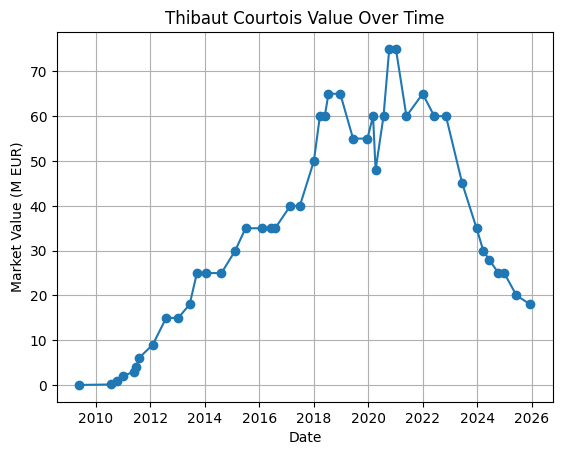

In [80]:
import matplotlib.pyplot as plt

player_id = 108390  # Example: Thibaut Courtois
player_df = df_clean[df_clean['player_id'] == player_id]

plt.plot(player_df['valuation_date'], player_df['value_eur']/1e6, marker='o')
plt.title(f"{player_df['name'].iloc[0]} Value Over Time")
plt.xlabel("Date")
plt.ylabel("Market Value (M EUR)")
plt.grid(True)
plt.show()

In [82]:
df_clean.to_csv(r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Cleaned.csv", index=False)

In [3]:
import dash
from dash import dcc, html, Input, Output
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv(r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Cleaned.csv")

# Convert date column
df['valuation_date'] = pd.to_datetime(df['valuation_date'])

# Initialize Dash app
app = dash.Dash(__name__)
app.title = "Football Player Market Values"

# Layout
app.layout = html.Div([

    html.H1(
        "Football Player Market Value Prediction Dashboard",
        style={'textAlign': 'center'}
    ),

    html.Br(),

    # Player Dropdown
    html.Div([
        html.Label("Select Player:"),
        dcc.Dropdown(
            id='player-dropdown',
            options=[
                {'label': name, 'value': pid}
                for pid, name in df[['player_id', 'name']].drop_duplicates().values
            ],
            value=df['player_id'].iloc[0],
            clearable=False
        )
    ], style={'width': '50%', 'margin': 'auto'}),

    html.Br(),

    # Graph
    dcc.Graph(id='value-over-time'),

    html.Br(),

    # Metric Selection
    html.Div([
        html.Label("Select Metric:"),
        dcc.RadioItems(
            id='metric-radio',
            options=[
                {'label': 'Market Value (€)', 'value': 'value_eur'},
                {'label': 'Growth %', 'value': 'value_growth_pct'}
            ],
            value='value_eur',
            labelStyle={'display': 'inline-block', 'margin-right': '15px'}
        )
    ], style={'width': '50%', 'margin': 'auto'}),

])


# Callback for updating graph
@app.callback(
    Output('value-over-time', 'figure'),
    Input('player-dropdown', 'value'),
    Input('metric-radio', 'value')
)

def update_graph(player_id, metric):

    player_df = df[df['player_id'] == player_id].sort_values('valuation_date')

    # Convert date to ordinal for ML model
    player_df['date_ordinal'] = player_df['valuation_date'].map(pd.Timestamp.toordinal)

    X = player_df[['date_ordinal']]
    y = player_df[metric]

    # Train prediction model
    model = LinearRegression()
    model.fit(X, y)

    # Create future dates for prediction (180 days)
    future_dates = pd.date_range(
        player_df['valuation_date'].max(),
        periods=180
    )

    future_ordinals = pd.DataFrame({
        'date_ordinal': future_dates.map(pd.Timestamp.toordinal)
    })

    predictions = model.predict(future_ordinals)

    # Create prediction dataframe
    future_df = pd.DataFrame({
        'valuation_date': future_dates,
        'prediction': predictions
    })

    # Plot graph
    fig = go.Figure()

    # Actual values
    fig.add_trace(
        go.Scatter(
            x=player_df['valuation_date'],
            y=player_df[metric],
            mode='lines+markers',
            name='Actual Value'
        )
    )

    # Predicted values
    fig.add_trace(
        go.Scatter(
            x=future_df['valuation_date'],
            y=future_df['prediction'],
            mode='lines',
            name='Predicted Value',
            line=dict(dash='dash')
        )
    )

    fig.update_layout(
        title=f"{player_df['name'].iloc[0]} - Market Value Prediction",
        xaxis_title="Date",
        yaxis_title=metric.replace("_", " "),
        template='plotly_white'
    )

    return fig


# Run app
if __name__ == '__main__':
    app.run(debug=True)

In [18]:
dict_df = pd.read_csv(r"C:\Users\pc\Desktop\foot_ball_data\Football_Player_Market_Value_Trajectories\data_dictionary.csv")

dict_df

,column,type,description
0,player_id,string,Transfermarkt unique player ID
1,name,string,Player full name
2,age,int,Current age (at time of scrape)
3,nationality,string,Player nationality country
4,position,string,Specific position (e.g. Centre-Forward)
5,position_group,string,Grouped position: Forward / Midfielder / Defen...
6,current_club,string,Club at time of scrape
7,league_name,string,League the player was listed in (Premier Leagu...
8,current_value_eur,float,Current market value in EUR
9,current_value_tier,string,Bucketed tier: World Class / Elite / Top / Reg...
